# Power Analysis for Flooding Detection

This notebook performs a power analysis to determine the probability of detecting at least one flooded image in various census units (Tracts, Block Groups, and Blocks), assuming a certain percentage of images in a flooded area are actually flooded.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

## 1. Load Data & Calculate Image Counts per Census Unit

In [2]:
# Load dashcam metadata
md_path = '../../data/processed/md.csv'
df_md = pd.read_csv(md_path)
df_md = df_md.dropna(subset=['gps_info.latitude', 'gps_info.longitude'])
print(f"Loaded {len(df_md)} dashcam records.")

# Create GeoDataFrame for dashcam images
gdf_dashcam = gpd.GeoDataFrame(
    df_md, 
    geometry=gpd.points_from_xy(df_md['gps_info.longitude'], df_md['gps_info.latitude']),
    crs="EPSG:4326"
)

Loaded 926212 dashcam records.


In [3]:
def get_image_counts(geojson_path, gdf_dashcam):
    gdf_census = gpd.read_file(geojson_path)
    if gdf_census.crs != gdf_dashcam.crs:
        gdf_census = gdf_census.to_crs(gdf_dashcam.crs)
        
    # Perform spatial join
    joined = gpd.sjoin(gdf_dashcam, gdf_census, how="inner", predicate="within")
    
    # Identify ID column
    possible_ids = ['GEOID', 'geoid', 'BoroCT2020', 'cb2020', 'boroct2020', 'gid', 'id']
    id_col = next((col for col in possible_ids if col in gdf_census.columns), gdf_census.columns[0])
    
    # Aggregate counts
    counts = joined[id_col].value_counts().rename('image_count')
    
    # Merge back
    gdf_coverage = gdf_census.merge(counts, left_on=id_col, right_index=True, how='left')
    gdf_coverage['image_count'] = gdf_coverage['image_count'].fillna(0).astype(int)
    
    return gdf_coverage

CBG_PATH = "../../aggregation/geo/data/cbg-nyc-2020.geojson"
CB_PATH = "../../aggregation/geo/data/cb-nyc-2020.geojson"
CT_PATH = "../../aggregation/geo/data/ct-nyc-2020.geojson"

print("Analyzing Tracts...")
gdf_ct = get_image_counts(CT_PATH, gdf_dashcam)
print("Analyzing Block Groups...")
gdf_cbg = get_image_counts(CBG_PATH, gdf_dashcam)
print("Analyzing Blocks...")
gdf_cb = get_image_counts(CB_PATH, gdf_dashcam)

Analyzing Tracts...
Analyzing Block Groups...
Analyzing Blocks...


## 2. Power Analysis

We perform a power analysis for each tract (and other census units). Imagine $p$ percent of images are flooded in a given tract and we have $N$ images in that tract. The probability we'll have at least one flooded image is $1 - (1 - p)^N$.

This analysis answers the question: **"Do we have enough images in a tract that we have a pretty good chance of detecting some flooding if it is in fact occurring?"**

We can then say: "Ok, for $XX\%$ of tracts, we have at least a 95% chance of having at least one flooded image if $p\%$ of images are flooded."

In [4]:
def calculate_detection_probability(N, p):
    return 1 - (1 - p)**N

p_values = [0.5, 0.25, 0.1]
geographies = [
    ("Census Tracts", gdf_ct),
    ("Census Block Groups", gdf_cbg),
    ("Census Blocks", gdf_cb)
]

results = []

for p in p_values:
    for name, gdf in geographies:
        probs = calculate_detection_probability(gdf['image_count'], p)
        pct_90 = (probs >= 0.90).sum() / len(gdf) * 100
        pct_95 = (probs >= 0.95).sum() / len(gdf) * 100
        pct_99 = (probs >= 0.99).sum() / len(gdf) * 100
        
        results.append({
            "p": p,
            "Geography": name,
            "% Units with Prob >= 90%": f"{pct_90:.2f}%",
            "% Units with Prob >= 95%": f"{pct_95:.2f}%",
            "% Units with Prob >= 99%": f"{pct_99:.2f}%"
        })

df_results = pd.DataFrame(results)
df_results

,p,Geography,% Units with Prob >= 90%,% Units with Prob >= 95%,% Units with Prob >= 99%
0,0.50,Census Tracts,99.74%,99.66%,99.61%
1,0.50,Census Block Groups,95.71%,95.09%,94.15%
2,0.50,Census Blocks,69.65%,65.48%,58.34%
3,0.25,Census Tracts,99.48%,99.40%,99.01%
4,0.25,Census Block Groups,92.92%,91.92%,87.81%
5,0.25,Census Blocks,52.04%,46.76%,35.05%
6,0.10,Census Tracts,98.45%,97.46%,95.53%
7,0.10,Census Block Groups,83.24%,77.70%,64.99%
8,0.10,Census Blocks,28.67%,22.33%,14.16%


## 3. Visualization

### 3.1 Detection Probability vs. Number of Images
How many images do we need to reach a high detection probability for different $p$ values?

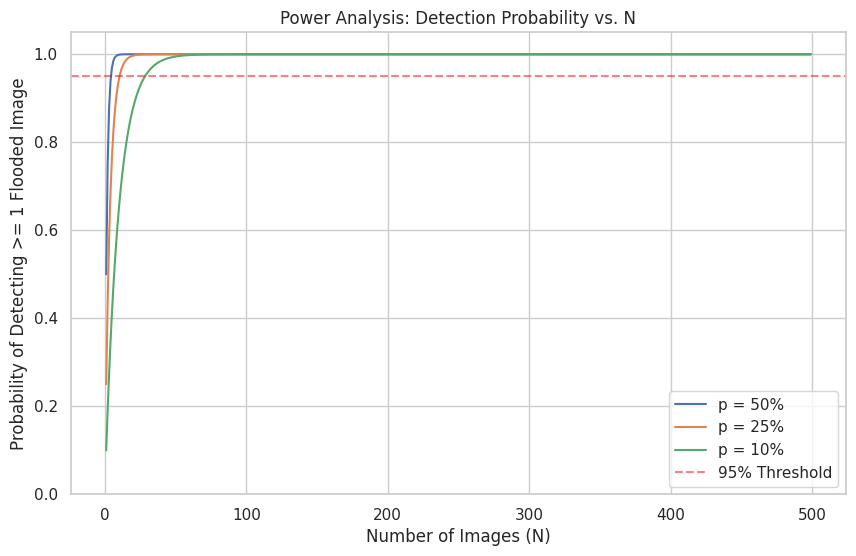

p=50%: 99.7% of tracts have >= 90% detection probability
p=25%: 99.5% of tracts have >= 90% detection probability
p=10%: 98.5% of tracts have >= 90% detection probability


In [5]:
N_range = np.arange(1, 500)
plt.figure(figsize=(10, 6))

for p in p_values:
    probs = calculate_detection_probability(N_range, p)
    plt.plot(N_range, probs, label=f'p = {p*100:.0f}%')

plt.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95% Threshold')
plt.xlabel('Number of Images (N)')
plt.ylabel('Probability of Detecting >= 1 Flooded Image')
plt.title('Power Analysis: Detection Probability vs. N')
plt.legend()
plt.ylim(0, 1.05)
plt.show()

# In what fraction of tracts do you have at least 90% chance of detecting flooding?
for p in [0.5, 0.25, 0.1]:
    probs = calculate_detection_probability(gdf_ct['image_count'], p)
    frac_90 = (probs >= 0.90).mean()
    print(f"p={p*100:.0f}%: {frac_90*100:.1f}% of tracts have >= 90% detection probability")

### 3.2 Distribution of Detection Probabilities (p = 20%)
Following the specific example: in what percentage of tracts would we detect flooding if 20% of images were truly flooded?

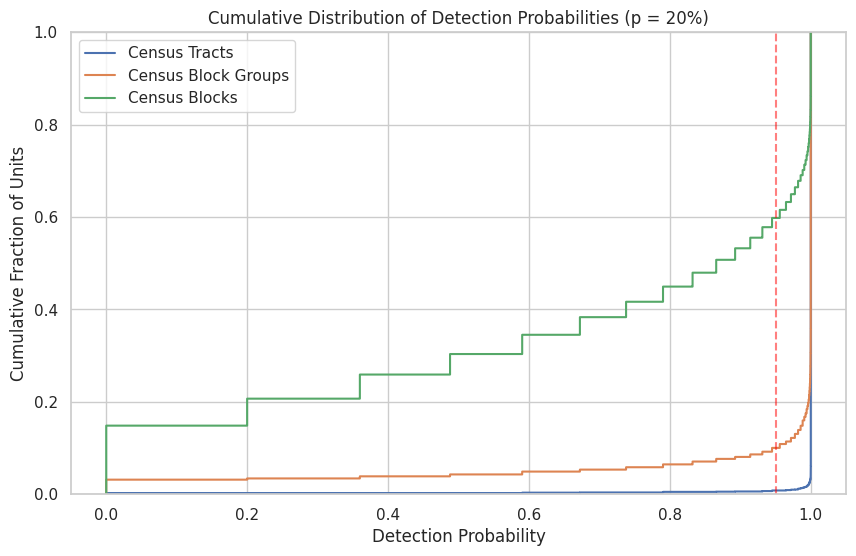

In [6]:
p_fixed = 0.20
plt.figure(figsize=(10, 6))

for name, gdf in geographies:
    probs = calculate_detection_probability(gdf['image_count'], p_fixed)
    sns.ecdfplot(probs, label=name)

plt.axvline(0.95, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Detection Probability')
plt.ylabel('Cumulative Fraction of Units')
plt.title(f'Cumulative Distribution of Detection Probabilities (p = {p_fixed*100:.0f}%)')
plt.legend()
plt.show()

## 4. Summary Table for Paper

In [7]:
p_values_extended = [0.01, 0.05, 0.1, 0.2, 0.5]
summary_rows = []

for name, gdf in geographies:
    row = {"Geography": name}
    for p in p_values_extended:
        probs = calculate_detection_probability(gdf['image_count'], p)
        pct_90 = (probs >= 0.90).sum() / len(gdf) * 100
        row[f"p={p*100:.0f}%"] = f"{pct_90:.2f}%"
    summary_rows.append(row)

df_summary_power = pd.DataFrame(summary_rows)
df_summary_power

,Geography,p=1%,p=5%,p=10%,p=20%,p=50%
0,Census Tracts,47.53%,95.31%,98.45%,99.40%,99.74%
1,Census Block Groups,12.35%,64.17%,83.24%,91.92%,95.71%
2,Census Blocks,0.94%,13.81%,28.67%,46.76%,69.65%


In [ ]:
import constants as c
from pathlib import Path
PAPER_PATH = Path(c.PAPER_PATH)
output_dir = PAPER_PATH / "tables"
output_dir.mkdir(parents=True, exist_ok=True)
with open(output_dir / "power_analysis_summary.tex", "w") as f:
    f.write(df_summary_power.to_latex(index=False, 
                                  caption="Percentage of census units with $\\ge 90\\%$ detection probability for various flooding fractions $p$", 
                                  label="tab:power_analysis_summary"))